# Dawid–Skene EM

## setup

In [16]:
import os, re, json, math
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pandas as pd

CLASSES = ["High","Good","Moderate","Bad","Poor"]
C = len(CLASSES)
CLS_TO_ID = {c:i for i,c in enumerate(CLASSES)}

def tidy_label(x):
    if x is None or (isinstance(x,float) and pd.isna(x)): return None
    s = str(x).strip().lower().replace('_',' ').replace('-',' ')
    s = s.title()
    return {"High":"High","Good":"Good","Moderate":"Moderate","Bad":"Bad","Poor":"Poor"}.get(s, None)

def entropy(p: np.ndarray) -> float:
    q = np.clip(p, 1e-12, 1.0)
    return float(-np.sum(q*np.log(q)))


## load predictions

In [17]:
def infer_label_column(df: pd.DataFrame) -> str:
    candidates = [c for c in df.columns if c != "SamplingOperations_code"]
    if len(candidates) == 1: return candidates[0]
    for name in ["IBD_EQR_Status","predictions","label","class","y_hat","y"]:
        if name in df.columns: return name
    raise ValueError(f"Cannot infer label column from {df.columns.tolist()}")

def resolve_dir(win_like: str, posix_like: str) -> Path:
    p1 = Path(win_like); 
    if p1.exists(): return p1
    p2 = Path(posix_like)
    if p2.exists(): return p2
    return p1  # may fail later if not found

def load_label_matrix(input_dir: Path) -> Tuple[np.ndarray, List[str], List[str]]:
    exts = (".csv",".tsv",".parquet",".feather")
    paths = sorted([p for p in input_dir.iterdir() if p.suffix.lower() in exts])
    if not paths:
        raise RuntimeError(f"No prediction files found in {input_dir}")
    series_list, file_names = [], []
    for p in paths:
        if p.suffix.lower()==".csv":      df = pd.read_csv(p)
        elif p.suffix.lower()==".tsv":    df = pd.read_csv(p, sep="\t")
        elif p.suffix.lower()==".parquet":df = pd.read_parquet(p)
        elif p.suffix.lower()==".feather":df = pd.read_feather(p)
        else: continue

        if "SamplingOperations_code" in df.columns:
            df = df.copy()
            df["SamplingOperations_code"] = df["SamplingOperations_code"].astype(str)
            df = df.set_index("SamplingOperations_code")
        else:
            if df.index.name != "SamplingOperations_code":
                if df.columns[0] == "SamplingOperations_code":
                    df = df.set_index(df.columns[0])
                else:
                    raise ValueError(f"{p.name} lacks 'SamplingOperations_code' index/column.")
            df.index = df.index.astype(str)

        label_col = infer_label_column(df.reset_index())
        s = df[label_col].map(tidy_label)
        series_list.append(s)
        file_names.append(p.name)

    items = sorted(set().union(*[set(s.index) for s in series_list]))
    N, K = len(items), len(series_list)
    Y = -np.ones((N, K), dtype=np.int16)
    for k, s in enumerate(series_list):
        aligned = s.reindex(items)
        for i, lab in enumerate(aligned.values):
            if lab is None: continue
            Y[i, k] = CLS_TO_ID.get(lab, -1)
    return Y, items, file_names


## acc parser with fiked prior

In [18]:
def parse_accuracy_from_name(name: str) -> float:
    """
    Accepts: ...acc=0.816907.csv, ...acc=81.6907%.csv, ...acc=81.6907.csv
    Returns float in (0,1); clipped to [1e-3, 1-1e-3].
    """
    m = list(re.finditer(r'acc\s*=\s*([0-9]+(?:\.[0-9]+)?)\s*%?', name, flags=re.I))
    if not m: 
        return np.nan
    s = m[-1].group(1)
    has_pct = '%' in name[m[-1].start(): m[-1].end()]
    v = float(s)
    if has_pct or v > 1.0: v /= 100.0
    return float(np.clip(v, 1e-3, 1-1e-3))

def build_theta_fixed_from_accs(file_names: List[str]) -> Tuple[np.ndarray, List[float]]:
    accs = [parse_accuracy_from_name(fn) for fn in file_names]
    if any(np.isnan(accs)):
        bad = [file_names[i] for i,a in enumerate(accs) if np.isnan(a)]
        raise ValueError(f"Missing 'acc=' in filenames: {bad}")
    K = len(accs)
    theta = np.zeros((K, C, C), dtype=float)
    for k,a in enumerate(accs):
        off = (1.0 - a) / (C - 1)
        T = np.full((C, C), off, dtype=float)
        np.fill_diagonal(T, a)
        theta[k] = T
    return theta, accs


## fixed prior from accuracies

In [19]:
def infer_with_fixed_theta(Y: np.ndarray,
                           theta_fixed: np.ndarray,
                           tol: float = 1e-8,
                           max_iter: int = 200,
                           min_iters: int = 3,
                           temperature: float = 1.0):
    """
    Fixed-θ Dawid–Skene.
    E-step: γ_ic ∝ ( π_c * Π_k θ_k[c, l_ik] )^(1/temperature)
    M-step: π_c ← mean_i γ_ic
    Stops when max |π^{t+1} - π^t| < tol after at least min_iters.
    temperature < 1 sharpens confidence; >1 smooths.
    """
    N, K = Y.shape
    C = theta_fixed.shape[1]
    pi = np.full(C, 1.0/C, dtype=float)

    for it in range(1, max_iter+1):
        pi_prev = pi.copy()

        # E-step
        logP = np.log(np.clip(pi, 1e-15, None))[None, :].repeat(N, axis=0)  # (N,C)
        for k in range(K):
            l = Y[:, k]                          # (N,)
            m = l >= 0
            if not np.any(m): 
                continue
            L = l[m].astype(int)                 # (n_obs,)
            Tk = theta_fixed[k]                  # (C,C)
            add = np.log(np.clip(Tk[:, L].T, 1e-15, None))  # (n_obs,C)
            logP[m, :] += add

        # Temperature scaling
        if temperature != 1.0:
            logP /= max(1e-12, float(temperature))

        # Normalize rows -> γ
        mrow = logP.max(axis=1, keepdims=True)
        P = np.exp(logP - mrow)
        gamma = P / P.sum(axis=1, keepdims=True)

        # M-step for π only
        pi = gamma.mean(axis=0)
        pi /= pi.sum()

        # Convergence on π drift (stable; no ±inf issues)
        if it >= min_iters and np.max(np.abs(pi - pi_prev)) < tol:
            break

    return gamma, pi, it


## run it

In [20]:
# Directory with your files
dir_win   = r"results\cleaned"
dir_posix = "results/cleaned"
pred_dir = resolve_dir(dir_win, dir_posix)
assert pred_dir.exists(), f"Directory not found: {pred_dir}"

# Load label votes
Y, items, file_names = load_label_matrix(pred_dir)
print(f"N={Y.shape[0]}  K={Y.shape[1]}  files={len(file_names)}")

# Build fixed θ from known accuracies in filenames
theta_fixed, accs = build_theta_fixed_from_accs(file_names)
print(pd.DataFrame({"file": file_names, "accuracy": accs}))

# Inference
gamma, pi, iters = infer_with_fixed_theta(Y, theta_fixed, tol=1e-32, max_iter=200, temperature=0.01)
print(f"Converged in {iters} iterations.")

# Outputs
yhat_idx = np.argmax(gamma, axis=1)
y_hat = [CLASSES[j] for j in yhat_idx]
probs = pd.DataFrame(gamma, index=items, columns=[f"P({c})" for c in CLASSES])
out = probs.copy()
out["y_hat"] = y_hat
out["confidence"] = [1.0 - entropy(gamma[i])/math.log(C) for i in range(len(items))]
out["entropy"] = [entropy(gamma[i]) for i in range(len(items))]
out["n_votes"] = (Y >= 0).sum(axis=1)
out.index.name = "SamplingOperations_code"
display(out.head())

# Save near the predictions directory
out_dir = Path("results/yhat construction/em")
out_csv = out_dir / "Yhat_EM_Temp=0.01.csv"
out.to_csv(out_csv, index=True)

# Save θ and π to JSON
thetas = {}
for k, name in enumerate(file_names):
    T = theta_fixed[k]
    dfT = pd.DataFrame(T, index=[f"true:{c}" for c in CLASSES],
                          columns=[f"obs:{c}" for c in CLASSES])
    thetas[name] = {"accuracy": float(accs[k]),
                    "theta": dfT.round(6).to_dict(orient="index")}
payload = {
    "classes": CLASSES,
    "pi": {CLASSES[i]: float(pi[i]) for i in range(C)},
    "predictors": thetas
}
theta_json_path = pred_dir / "theta_fixed.json"
with open(theta_json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print(f"Wrote {out_csv}")
print(f"Wrote {theta_json_path}")


N=5063  K=16  files=16
                                  file  accuracy
0         98CBTPEPMIP_acc=0.914083.csv  0.914083
1                  99_acc=0.920798.csv  0.920798
2           99CBTPEPM_acc=0.920798.csv  0.920798
3                  BC_acc=0.820462.csv  0.820462
4                CBCr_acc=0.833695.csv  0.833695
5      CBFullTraining_acc=0.899664.csv  0.899664
6                CBph_acc=0.852459.csv  0.852459
7                   CBt_acc=0.8689.csv  0.868900
8       Interpolation_acc=0.311300.csv  0.311300
9    JAPredictionsXGB_acc=0.816907.csv  0.816907
10    RandomPredictions_acc=0.3075.csv  0.307500
11                RFG_acc=0.814100.csv  0.814100
12               RFpR_acc=0.802489.csv  0.802489
13            XGBTiF3_acc=0.568635.csv  0.568635
14  XGBTruncatedClean_acc=0.372300.csv  0.372300
15      XGBTruncatedRaw_acc=0.4999.csv  0.499900
Converged in 10 iterations.


,P(High),P(Good),P(Moderate),P(Bad),P(Poor),y_hat,confidence,entropy,n_votes
SamplingOperations_code,,,,,,,,,
S02000010_20080811,0.0,5.992805e-129,1.0,0.0,0.0,Moderate,1.0,1.105241e-10,16
S02000010_20100719,0.0,1.000000e+00,0.0,0.0,0.0,Good,1.0,1.105241e-10,16
S02000010_20150811,0.0,0.000000e+00,1.0,0.0,0.0,Moderate,1.0,1.105241e-10,16
S02000010_20170703,0.0,1.000000e+00,0.0,0.0,0.0,Good,1.0,1.105241e-10,16
S02000011_20100719,0.0,1.000000e+00,0.0,0.0,0.0,Good,1.0,1.105241e-10,16


Wrote results\yhat construction\em\Yhat_EM_Temp=0.01.csv
Wrote results\cleaned\theta_fixed.json


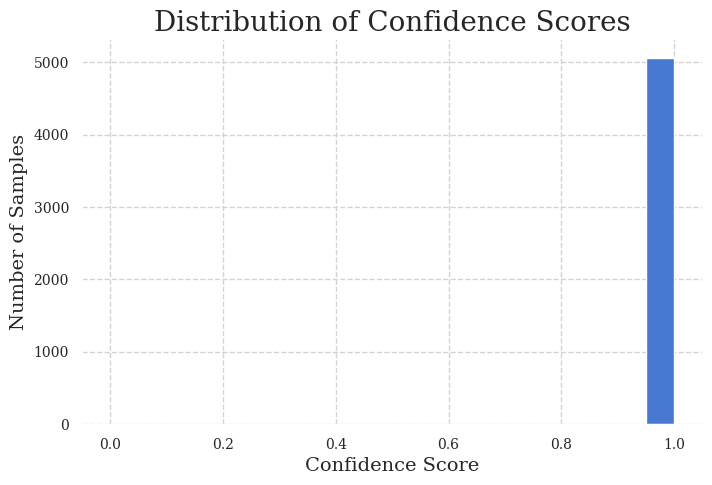

In [21]:
# plot the distribution of confidence scores
import matplotlib.pyplot as plt
from scripts import style
style.mpl_apply()  # Apply custom style setting 
plt.figure(figsize=(8,5))   
plt.hist(out["confidence"], bins=20, range=(0.0,1.0))
plt.title("Distribution of Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Samples")
plt.show()

## inferecnce with theta fixed

In [22]:
# Expected micro-accuracy and 95% CI
p_correct = gamma[np.arange(gamma.shape[0]), yhat_idx]
acc_exp = float(p_correct.mean())
se = float(np.sqrt(np.sum(p_correct * (1 - p_correct))) / len(p_correct))
ci95 = (max(0.0, acc_exp - 1.96*se), min(1.0, acc_exp + 1.96*se))

# Expected balanced accuracy (macro recall)
num = np.zeros(C); den = np.zeros(C)
for c in range(C):
    den[c] = float(np.sum(gamma[:, c]))
    num[c] = float(np.sum(gamma[yhat_idx == c, c]))
recalls = np.divide(num, np.clip(den, 1e-12, None))
bal_acc_exp = float(np.mean(recalls))

summary = pd.Series({
    "expected_micro_accuracy": acc_exp,
    "ci95_lower": ci95[0],
    "ci95_upper": ci95[1],
    "expected_balanced_accuracy": bal_acc_exp
})
display(summary)
summary.to_csv(pred_dir / "expected_accuracy_summary_fixedtheta.csv")
print(f"Wrote {pred_dir / 'expected_accuracy_summary_fixedtheta.csv'}")


expected_micro_accuracy       0.999950
ci95_lower                    0.999775
ci95_upper                    1.000000
expected_balanced_accuracy    0.999975
dtype: float64

Wrote results\cleaned\expected_accuracy_summary_fixedtheta.csv


In [23]:
out

,P(High),P(Good),P(Moderate),P(Bad),P(Poor),y_hat,confidence,entropy,n_votes
SamplingOperations_code,,,,,,,,,
S02000010_20080811,0.0,5.992805e-129,1.0,0.0,0.0,Moderate,1.0,1.105241e-10,16
S02000010_20100719,0.0,1.000000e+00,0.0,0.0,0.0,Good,1.0,1.105241e-10,16
S02000010_20150811,0.0,0.000000e+00,1.0,0.0,0.0,Moderate,1.0,1.105241e-10,16
S02000010_20170703,0.0,1.000000e+00,0.0,0.0,0.0,Good,1.0,1.105241e-10,16
S02000011_20100719,0.0,1.000000e+00,0.0,0.0,0.0,Good,1.0,1.105241e-10,16
...,...,...,...,...,...,...,...,...,...
S06940940_20100708,0.0,0.000000e+00,1.0,0.0,0.0,Moderate,1.0,1.105241e-10,16
S06940940_20230623,0.0,0.000000e+00,1.0,0.0,0.0,Moderate,1.0,1.105241e-10,16
S06960950_20160629,1.0,0.000000e+00,0.0,0.0,0.0,High,1.0,1.105241e-10,16


In [24]:
import numpy as np, math, pandas as pd

# assumes: gamma (N,C), items (list), y_hat (list of class names), CLASSES
yhat_idx = np.argmax(gamma, axis=1)
p_correct = gamma[np.arange(gamma.shape[0]), yhat_idx]       # P(true == ŷ_i | votes)

acc_exp = float(p_correct.mean())
# Normal approx. SE for mean of independent Bernoullis with probs p_i
se = float(np.sqrt(np.sum(p_correct * (1 - p_correct))) / len(p_correct))
ci95 = (max(0.0, acc_exp - 1.96*se), min(1.0, acc_exp + 1.96*se))

print(f"Expected micro-accuracy: {acc_exp:.4f}")
print(f"Approx. 95% CI: [{ci95[0]:.4f}, {ci95[1]:.4f}]")


Expected micro-accuracy: 1.0000
Approx. 95% CI: [0.9998, 1.0000]


In [25]:
# Expected TP for class c: sum_i γ_ic * 1[ŷ_i == c]
# Expected support for class c: sum_i γ_ic
num = np.zeros(len(CLASSES))
den = np.zeros(len(CLASSES))
for c in range(len(CLASSES)):
    den[c] = float(np.sum(gamma[:, c]))
    num[c] = float(np.sum(gamma[yhat_idx == c, c]))
recalls = np.divide(num, np.clip(den, 1e-12, None))
bal_acc_exp = float(np.mean(recalls))

rec_df = pd.DataFrame({
    "class": CLASSES,
    "E[support]": den,
    "E[TP]": num,
    "E[recall_c]": recalls
})
display(rec_df)
print(f"Expected balanced accuracy: {bal_acc_exp:.4f}")


,class,E[support],E[TP],E[recall_c]
0,High,1061.991642,1061.991642,1.000000
1,Good,2077.191608,2076.970191,0.999893
2,Moderate,1640.816750,1640.786941,0.999982
3,Bad,25.000000,25.000000,1.000000
4,Poor,258.000000,258.000000,1.000000


Expected balanced accuracy: 1.0000


In [26]:
# M[c, l] = sum_i γ_ic * 1[ŷ_i = l];  row-normalize by E[support(c)]
K = len(CLASSES)
M = np.zeros((K, K))
for c in range(K):
    for l in range(K):
        M[c, l] = float(np.sum(gamma[yhat_idx == l, c]))
row_sums = M.sum(axis=1, keepdims=True)
M_rownorm = M / np.clip(row_sums, 1e-12, None)

conf_exp = pd.DataFrame(M_rownorm, index=[f"true:{c}" for c in CLASSES],
                                     columns=[f"pred:{c}" for c in CLASSES]).round(4)
display(conf_exp)


,pred:High,pred:Good,pred:Moderate,pred:Bad,pred:Poor
true:High,1.0,0.0000,0.0000,0.0,0.0
true:Good,0.0,0.9999,0.0001,0.0,0.0
true:Moderate,0.0,0.0000,1.0000,0.0,0.0
true:Bad,0.0,0.0000,0.0000,1.0,0.0
true:Poor,0.0,0.0000,0.0000,0.0,1.0


In [27]:
# confidence_i = max_c γ_ic ; expected correctness equals p_correct
conf = p_correct.copy()
q = pd.qcut(conf, q=10, duplicates="drop")
cal = pd.DataFrame({"conf": conf, "p_correct": p_correct, "bin": q}) \
        .groupby("bin").agg(E_conf=("conf","mean"), E_acc=("p_correct","mean"),
                            count=("conf","size")).reset_index(drop=True)
display(cal)


C:\Users\herie\AppData\Local\Temp\ipykernel_4524\1667966124.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin").agg(E_conf=("conf","mean"), E_acc=("p_correct","mean"),


,E_conf,E_acc,count
0,0.99995,0.99995,5063


In [28]:
yhat = out[['y_hat']].copy()
yhat.index.name = "SamplingOperations_code"
# rename the col yhat to IBD_EQR_Status
yhat = yhat.rename(columns={"y_hat": "IBD_EQR_Status"})
yhat.to_csv("results/yhat construction/em/Yhat_EM.csv", index=True)

# minicompare

In [29]:
import pandas as pd
pred = pd.read_csv("notebooks/05 David-Skene EM/results/CBt_acc=0.8689.csv", index_col="SamplingOperations_code")

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/05 David-Skene EM/results/CBt_acc=0.8689.csv'

In [ ]:
coincidence = pred.merge(yhat, left_index=True, right_index=True)
coincidence['match'] = coincidence['IBD_EQR_Status_x'] == coincidence['IBD_EQR_Status_y']
accuracy = coincidence['match'].mean()
accuracy

np.float64(0.9198304785449408)